In [2]:
import json
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import (
    RandomizedSearchCV, StratifiedKFold,
    cross_val_predict, cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

print('Libraries loaded ✅')


Libraries loaded ✅


In [3]:
df = pd.read_csv('data/shah_alam_labeled2.csv')

print(f'Shape: {df.shape}')
print(f'\nClass distribution:')
print(df['business_type'].value_counts())

Shape: (56, 17)

Class distribution:
business_type
Community Services     20
Leisure & Lifestyle    13
Retail & Commerce       9
Business & Trade        9
Food & Beverage         5
Name: count, dtype: int64


In [4]:
MODEL_FEATURES = [
    'population', 'food_beverage', 'retail_outlet', 'service_business',
    'entertainment', 'educational_inst', 'corporate_office', 'financial_inst',
    'shopping_mall', 'automotive', 'healthcare', 'transportation',
    'amenity_diversity_index',
]

X     = df[MODEL_FEATURES].copy()
y_raw = df['business_type']

le = LabelEncoder()
y  = le.fit_transform(y_raw)

print(f'Features : {X.shape[1]}')
print(f'Classes  : {le.classes_}')

Features : 13
Classes  : ['Business & Trade' 'Community Services' 'Food & Beverage'
 'Leisure & Lifestyle' 'Retail & Commerce']


In [5]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'Categorical cols: {categorical_cols}')  # should be empty

def build_pipeline(classifier):
    preprocessor = ColumnTransformer(
        transformers=[('cat', Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols)],
        remainder='passthrough'
    )
    return Pipeline([('preprocessor', preprocessor), ('model', classifier)])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('Pipeline builder and SKF ready ✅')

Categorical cols: []
Pipeline builder and SKF ready ✅


In [6]:
print('🌲 Baseline Random Forest — 5-Fold Stratified CV...')

rf_baseline = build_pipeline(RandomForestClassifier(random_state=42))

rf_cv = cross_validate(
    rf_baseline, X, y, cv=skf,
    scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
    return_train_score=True
)

print(f"All Folds Accuracy : {rf_cv['test_accuracy']}")
print(f"Mean Accuracy      : {rf_cv['test_accuracy'].mean()*100:.2f}%")
print(f"CV Precision       : {rf_cv['test_precision_macro'].mean():.4f}")
print(f"CV Recall          : {rf_cv['test_recall_macro'].mean():.4f}")
print(f"CV F1 (macro)      : {rf_cv['test_f1_macro'].mean():.4f}")

y_pred_baseline = cross_val_predict(rf_baseline, X, y, cv=skf)
print('\nClassification Report (Baseline):')
print(classification_report(y, y_pred_baseline, target_names=le.classes_, zero_division=0))

🌲 Baseline Random Forest — 5-Fold Stratified CV...
All Folds Accuracy : [0.41666667 0.54545455 0.63636364 0.54545455 0.63636364]
Mean Accuracy      : 55.61%
CV Precision       : 0.4742
CV Recall          : 0.5033
CV F1 (macro)      : 0.4546

Classification Report (Baseline):
                     precision    recall  f1-score   support

   Business & Trade       0.56      0.56      0.56         9
 Community Services       0.71      0.85      0.77        20
    Food & Beverage       0.67      0.40      0.50         5
Leisure & Lifestyle       0.42      0.38      0.40        13
  Retail & Commerce       0.25      0.22      0.24         9

           accuracy                           0.55        56
          macro avg       0.52      0.48      0.49        56
       weighted avg       0.54      0.55      0.54        56



In [7]:
print('⚙️  RandomizedSearchCV with scoring=f1_macro...')

param_dist = {
    'model__n_estimators':      [50, 100, 200, 300],
    'model__max_depth':         [None, 5, 10, 15, 20],
    'model__min_samples_split': [2, 4, 6, 8],
    'model__min_samples_leaf':  [1, 2, 3],
    'model__max_features':      ['sqrt', 'log2', None],
    'model__bootstrap':         [True, False],
    'model__class_weight':      ['balanced', 'balanced_subsample', None],
}

rf_search = RandomizedSearchCV(
    build_pipeline(RandomForestClassifier(random_state=42)),
    param_distributions=param_dist,
    n_iter=30,
    cv=skf,
    scoring='f1_macro',   # KEY CHANGE — was 'accuracy'
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_search.fit(X, y)

print(f'\nBest CV F1 (macro) : {rf_search.best_score_*100:.2f}%')
print(f'Best Params        : {rf_search.best_params_}')

⚙️  RandomizedSearchCV with scoring=f1_macro...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV F1 (macro) : 64.10%
Best Params        : {'model__n_estimators': 100, 'model__min_samples_split': 8, 'model__min_samples_leaf': 2, 'model__max_features': None, 'model__max_depth': None, 'model__class_weight': 'balanced_subsample', 'model__bootstrap': False}


In [8]:
print('📊 Evaluating best model with full 5-Fold CV...')

best_model = rf_search.best_estimator_

best_cv = cross_validate(
    best_model, X, y, cv=skf,
    scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
    return_train_score=True
)

y_pred_best = cross_val_predict(best_model, X, y, cv=skf)

print('=' * 55)
print('  TUNED MODEL — FINAL CV RESULTS')
print('=' * 55)
print(f"All Folds Accuracy : {best_cv['test_accuracy']}")
print(f"Mean CV Accuracy   : {best_cv['test_accuracy'].mean()*100:.2f}% (±{best_cv['test_accuracy'].std()*100:.2f}%)")
print(f"Mean CV Precision  : {best_cv['test_precision_macro'].mean():.4f}")
print(f"Mean CV Recall     : {best_cv['test_recall_macro'].mean():.4f}")
print(f"Mean CV F1 (macro) : {best_cv['test_f1_macro'].mean():.4f}")
print()
print('Classification Report (Cross-Validated):')
print(classification_report(y, y_pred_best, target_names=le.classes_, zero_division=0))

📊 Evaluating best model with full 5-Fold CV...
  TUNED MODEL — FINAL CV RESULTS
All Folds Accuracy : [0.66666667 0.72727273 0.63636364 0.45454545 0.90909091]
Mean CV Accuracy   : 67.88% (±14.67%)
Mean CV Precision  : 0.6560
Mean CV Recall     : 0.6833
Mean CV F1 (macro) : 0.6410

Classification Report (Cross-Validated):
                     precision    recall  f1-score   support

   Business & Trade       0.56      0.56      0.56         9
 Community Services       0.85      0.85      0.85        20
    Food & Beverage       0.57      0.80      0.67         5
Leisure & Lifestyle       0.62      0.38      0.48        13
  Retail & Commerce       0.58      0.78      0.67         9

           accuracy                           0.68        56
          macro avg       0.64      0.67      0.64        56
       weighted avg       0.68      0.68      0.67        56



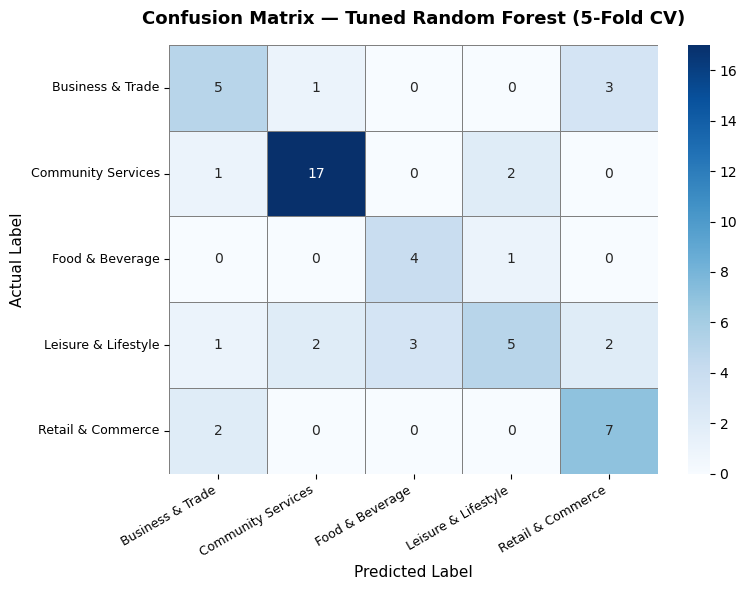

Confusion Matrix saved as confusion_matrix.png ✅


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    linewidths=0.5,
    linecolor='gray'
)

plt.title('Confusion Matrix — Tuned Random Forest (5-Fold CV)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Actual Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('Confusion Matrix saved as confusion_matrix.png ✅')